# Detección de discurso de odio en español con LSTM: 

## Estudiantes: Camilo Arciniegas - Deibi Bastidas

## Planteamiento del problema

El discurso de odio en redes sociales — contenido que ataca, denigra o incita a la violencia contra personas por pertenecer a un grupo protegido (etnia, género, orientación sexual, nacionalidad, religión, etc.) — tiene consecuencias reales: normaliza la hostilidad hacia esos grupos, degrada el espacio público de conversación, y en plataformas con millones de publicaciones diarias es imposible moderarlo manualmente. Por eso las plataformas dependen de sistemas automáticos como primer filtro, que luego escalan los casos dudosos a revisión humana.

Detectarlo automáticamente en español no es trivial:
- El español se habla en más de 20 países, con argot y expresiones muy distintas entre sí; lo que es un insulto fuerte en un país puede ser una expresión coloquial casi inofensiva en otro.
- El texto de redes sociales es corto, informal, con errores ortográficos, abreviaturas, menciones y hashtags.
- La frontera entre "lenguaje ofensivo" y "discurso de odio" es sutil: insultar a una persona no es lo mismo que atacar a un grupo por una característica protegida, pero léxicamente ambos casos comparten muchas palabras (insultos, groserías).
- Distintos estudios y equipos de anotadores no siempre coinciden en qué cuenta como odio, lo que introduce ruido en las etiquetas cuando se combinan varios datasets — que es justamente el caso del dataset que usamos aquí.

**El dataset** (`manueltonneau/spanish-hate-speech-superset`) agrega varios corpus públicos de habla hispana (incluyendo HatEval 2019 y HaterNet) en un único conjunto de cerca de 30 000 tweets etiquetados como odio / no odio. Esto da volumen suficiente para entrenar una red neuronal desde cero, a cambio de heredar cierta inconsistencia de criterio entre sub-fuentes — algo que exploramos en el EDA.

**Por qué una LSTM es una propuesta razonable:** a diferencia de un enfoque de bolsa de palabras (como TF-IDF), una LSTM procesa el texto en orden y puede capturar dependencias entre palabras distantes — por ejemplo, negaciones ("no odio a nadie" vs. "odio a la gente") o intensificadores que cambian el sentido de una frase completa. Eso es relevante en un problema donde el significado depende del contexto y no solo de qué palabras aparecen. Para no dar por sentado que ese poder extra realmente se traduce en mejor desempeño, también entrenamos un baseline de TF-IDF + Regresión Logística: nos permite cuantificar cuánto aporta modelar el orden de las palabras frente a un enfoque mucho más simple y barato de entrenar.

**Qué se hace en este notebook, en orden:**
1. Carga y análisis exploratorio del dataset (EDA).
2. Tokenización simple por palabras y análisis de vocabulario.
3. Baseline: TF-IDF + Regresión Logística.
4. Manejo del desbalance de clases.
5. Tres variantes de arquitectura LSTM (unidireccional, bidireccional, bidireccional + atención), entrenadas y comparadas bajo las mismas condiciones.
6. Selección del mejor modelo, calibración de umbral, evaluación final.
7. Análisis de errores por sub-fuente del dataset.
8. Demo con ejemplos manuales.
9. Conclusiones.

#### Referencias
- Dataset: https://huggingface.co/datasets/manueltonneau/spanish-hate-speech-superset (combina corpora públicos como HatEval 2019 en español y HaterNet)


In [32]:
import warnings

warnings.filterwarnings('ignore')

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

In [33]:
!test '{IN_COLAB}' = 'True' && sudo apt-get update -y
!test '{IN_COLAB}' = 'True' && sudo apt-get install python3.10 python3.10-distutils python3.10-lib2to3 -y
!test '{IN_COLAB}' = 'True' && sudo update-alternatives --install /usr/local/bin/python python /usr/bin/python3.11 2
!test '{IN_COLAB}' = 'True' && sudo update-alternatives --install /usr/local/bin/python python /usr/bin/python3.10 1
!test '{IN_COLAB}' = 'True' && pip install lightning datasets torchmetrics scikit-learn pandas matplotlib

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64  InRelease
Get:3 https://cli.github.com/packages stable InRelease [4,685 B]
Hit:4 http://archive.ubuntu.com/ubuntu noble InRelease
Hit:5 https://r2u.stat.illinois.edu/ubuntu noble InRelease
Hit:6 http://archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu noble-backports InRelease
Hit:8 http://security.ubuntu.com/ubuntu noble-security InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu noble InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu noble InRelease
Fetched 4,685 B in 2s (2,202 B/s)
Reading package lists... Done
W: https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Skipping acquire of c

## Cargando el dataset

Cargamos el dataset desde un archivo CSV local (exportado previamente desde el dataset en Hugging Face). La columna de etiqueta se llama `labels` (no `label`), con valores flotantes: `0.0` = no odio, `1.0` = odio.

In [34]:
from datasets import load_dataset
import warnings
import os

warnings.filterwarnings("ignore")
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

try:
    dataset = load_dataset('csv', data_files='/content/sample_data/es_hf_102024.csv', split='train')
except Exception as e:
    print(f"No se pudo cargar el CSV en la ruta esperada ({e}); ajusta la ruta si es necesario.")
    raise

dataset

Dataset({
    features: ['text', 'labels', 'source', 'dataset', 'nb_annotators', 'tweet_id', 'post_author_country_location'],
    num_rows: 29855
})

In [35]:
# Miramos un registro completo: además del texto y la etiqueta, este
# dataset trae metadatos útiles para el EDA (fuente, país, número de
# anotadores) que vamos a aprovechar más abajo.
dataset[1]

{'text': '@USER @USER @USER Me carga en lo q se convirtió la 2da vuelta a la gobernación...una flaiterío.',
 'labels': 0.0,
 'source': 'Twitter',
 'dataset': 'chileno',
 'nb_annotators': 3,
 'tweet_id': 1402708213246697482,
 'post_author_country_location': 'Chile'}

## Análisis exploratorio de datos (EDA)

Antes de tocar el modelo, exploramos el dataset desde varios ángulos: balance de clases, longitud de los textos, composición por sub-fuente, procedencia geográfica y vocabulario asociado a cada clase. El objetivo no es solo "mirar los datos" sino que cada hallazgo informe una decisión concreta más adelante (sampler, métricas, análisis de errores, etc.).

In [36]:
from collections import Counter

label_counts = Counter(dataset['labels'])
total = sum(label_counts.values())
for label, count in sorted(label_counts.items()):
    print(f"Clase {label}: {count} ejemplos ({count/total:.1%})")

Clase 0.0: 22590 ejemplos (75.7%)
Clase 1.0: 7265 ejemplos (24.3%)


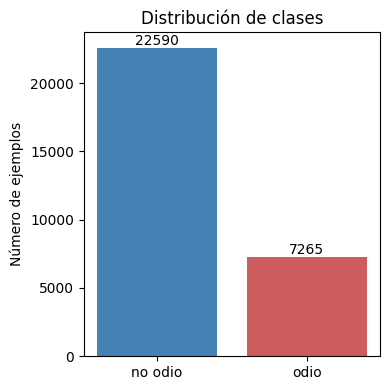

In [37]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4, 4))
labels_plot = ['no odio', 'odio']
counts_plot = [label_counts[0.0], label_counts[1.0]]
ax.bar(labels_plot, counts_plot, color=['steelblue', 'indianred'])
ax.set_ylabel('Número de ejemplos')
ax.set_title('Distribución de clases')
for i, v in enumerate(counts_plot):
    ax.text(i, v + 200, str(v), ha='center')
plt.tight_layout()
plt.show()

Se observa un desbalance entre las dos clases

In [38]:
text_lengths = [len(row['text']) for row in dataset]
print(f"Texto más corto: {min(text_lengths)}")
print(f"Texto más largo: {max(text_lengths)}")
print(f"Longitud promedio: {sum(text_lengths) / len(text_lengths):.1f}")

Texto más corto: 6
Texto más largo: 559
Longitud promedio: 129.3


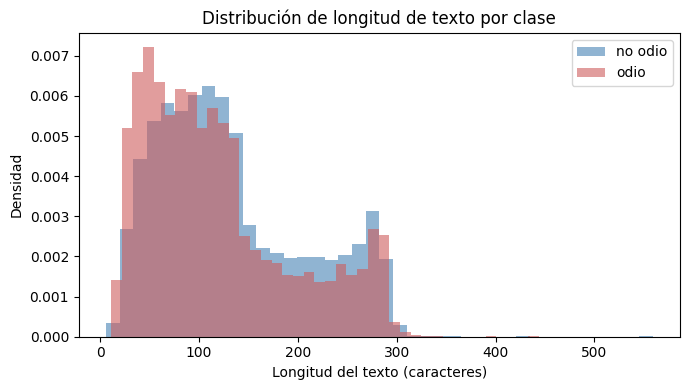

In [39]:
import matplotlib.pyplot as plt

# Comparamos la distribución de longitud entre clases: si "odio" y "no
# odio" tuvieran longitudes muy distintas, la longitud misma sería una
# señal (aunque débil) para el modelo; si son parecidas, el modelo tiene
# que apoyarse en el contenido, no en la forma.
lengths_odio = [len(t) for t, l in zip(dataset['text'], dataset['labels']) if l == 1.0]
lengths_no_odio = [len(t) for t, l in zip(dataset['text'], dataset['labels']) if l == 0.0]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(lengths_no_odio, bins=40, alpha=0.6, label='no odio', color='steelblue', density=True)
ax.hist(lengths_odio, bins=40, alpha=0.6, label='odio', color='indianred', density=True)
ax.set_xlabel('Longitud del texto (caracteres)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de longitud de texto por clase')
ax.legend()
plt.tight_layout()
plt.show()

### Composición por sub-fuente

Este dataset combina varios corpus (columna `dataset`), cada uno anotado en un estudio distinto. Si la proporción de "odio" varía mucho entre sub-fuentes, es una señal de que no todas comparten el mismo criterio de anotación

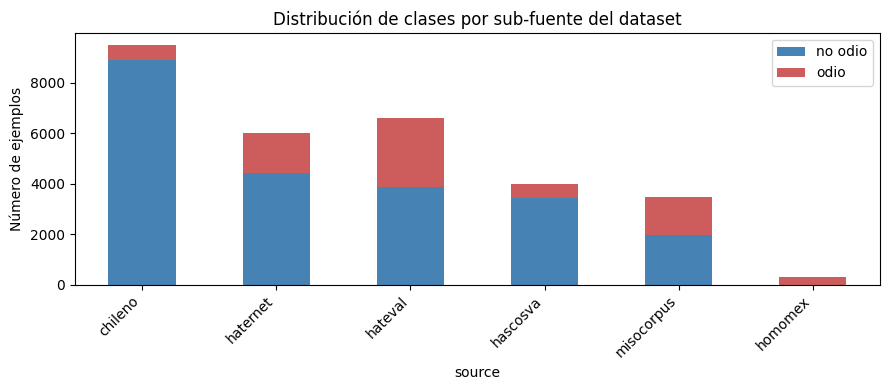

Proporción de 'odio' por sub-fuente:
source
homomex      100.0%
misocorpus    43.5%
hateval       41.5%
haternet      26.1%
hascosva      13.9%
chileno        6.3%


In [40]:
import pandas as pd
import matplotlib.pyplot as plt

source_df = pd.DataFrame({'source': dataset['dataset'], 'label': dataset['labels']})
source_counts = source_df.groupby(['source', 'label']).size().unstack(fill_value=0)
source_counts.columns = ['no odio', 'odio']
source_counts = source_counts.sort_values('no odio', ascending=False)

ax = source_counts.plot(kind='bar', stacked=True, figsize=(9, 4), color=['steelblue', 'indianred'])
ax.set_ylabel('Número de ejemplos')
ax.set_title('Distribución de clases por sub-fuente del dataset')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Proporción de "odio" dentro de cada sub-fuente.
prop_odio = (source_counts['odio'] / source_counts.sum(axis=1)).sort_values(ascending=False)
print("Proporción de 'odio' por sub-fuente:")
print(prop_odio.to_string(float_format=lambda x: f'{x:.1%}'))

### Procedencia geográfica y anotación

También revisamos de qué países viene el texto y cuántos anotadores etiquetaron cada ejemplo (más anotadores por ejemplo generalmente implica una etiqueta más confiable).

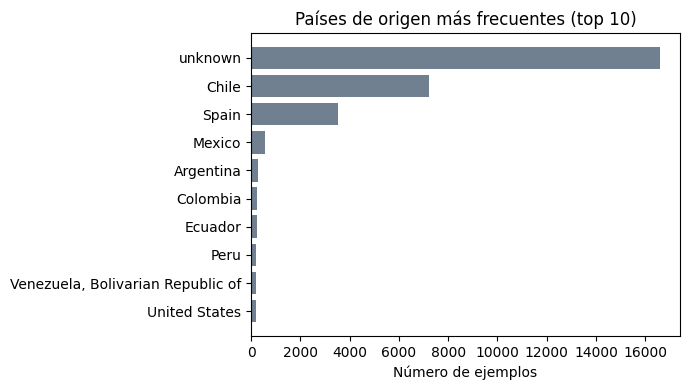

Distribución del número de anotadores por ejemplo:
  3 anotador(es): 23552 ejemplos (78.9%)
  4 anotador(es): 6303 ejemplos (21.1%)


In [41]:
import matplotlib.pyplot as plt
from collections import Counter

country_counts = Counter(c for c in dataset['post_author_country_location'] if c)
top_countries = country_counts.most_common(10)

fig, ax = plt.subplots(figsize=(7, 4))
countries, counts = zip(*top_countries)
ax.barh(countries[::-1], counts[::-1], color='slategray')
ax.set_xlabel('Número de ejemplos')
ax.set_title('Países de origen más frecuentes (top 10)')
plt.tight_layout()
plt.show()

annot_counts = Counter(dataset['nb_annotators'])
print("Distribución del número de anotadores por ejemplo:")
for n, c in sorted(annot_counts.items()):
    print(f"  {n} anotador(es): {c} ejemplos ({c/len(dataset):.1%})")

## Definiendo el Tokenizer

Construimos un tokenizador simple por palabras (en vez de uno preentrenado) porque el objetivo del ejercicio es implementar el pipeline completo desde cero. El tamaño del vocabulario (15.000 tokens) se elige en función del tamaño del dataset (30 000 textos cortos): un vocabulario mucho más grande dejaría muchas palabras con muy pocos ejemplos de entrenamiento, y sus embeddings terminarían casi sin entrenar.

In [42]:
import re
from collections import Counter

def simple_tokenizer(text):
    text = text.lower()
    text = re.sub(r"[^a-záéíóúüñ]+", " ", text)
    return text.strip().split()

token_counts = Counter()
for text in dataset["text"]:
    token_counts.update(simple_tokenizer(text))

# Nota: al iterar, Counter conserva el orden de primera aparición de cada
# clave, no el orden de frecuencia; esta selección toma las primeras
# 14 998 palabras distintas encontradas, no necesariamente las más
# frecuentes.
top_n_tokens = list(token_counts.keys())[:15000-2]

vocab = {"[PAD]": 0, "[UNK]": 1}
for token in top_n_tokens:
    vocab[token] = len(vocab)

def tokenize_text(text, max_length=64):
    tokens = simple_tokenizer(text)
    ids = [vocab.get(tok, vocab["[UNK]"]) for tok in tokens[:max_length]]
    ids += [vocab["[PAD]"]] * (max_length - len(ids))
    return ids

print(f"Vocabulario: {len(vocab)} tokens")

Vocabulario: 15000 tokens


In [43]:
# Tasa de tokens fuera de vocabulario (OOV): qué proporción de las
# palabras del corpus completo termina mapeada a [UNK]. Una tasa muy alta
# indicaría que el vocabulario es demasiado pequeño (se pierde
# información); una tasa muy baja sugiere que incluso se podría reducir
# el vocabulario sin perder cobertura real.
total_tokens = 0
oov_tokens = 0
for text in dataset['text']:
    toks = simple_tokenizer(text)
    total_tokens += len(toks)
    oov_tokens += sum(1 for t in toks if t not in vocab)

print(f"Tokens totales en el corpus: {total_tokens:,}")
print(f"Tasa de tokens fuera de vocabulario (OOV): {oov_tokens/total_tokens:.2%}")

Tokens totales en el corpus: 664,610
Tasa de tokens fuera de vocabulario (OOV): 11.62%


### Vocabulario asociado a cada clase

Más allá de cuántos ejemplos hay de cada clase, es útil ver *qué palabras* están sobrerrepresentadas en "odio" frente a "no odio". Esto también sirve de referencia: si el vocabulario asociado a "odio" es mayormente léxico explícito (insultos, términos discriminatorios), una parte del problema es "detectable por palabras clave" — lo cual conecta directamente con el baseline de TF-IDF que viene después.

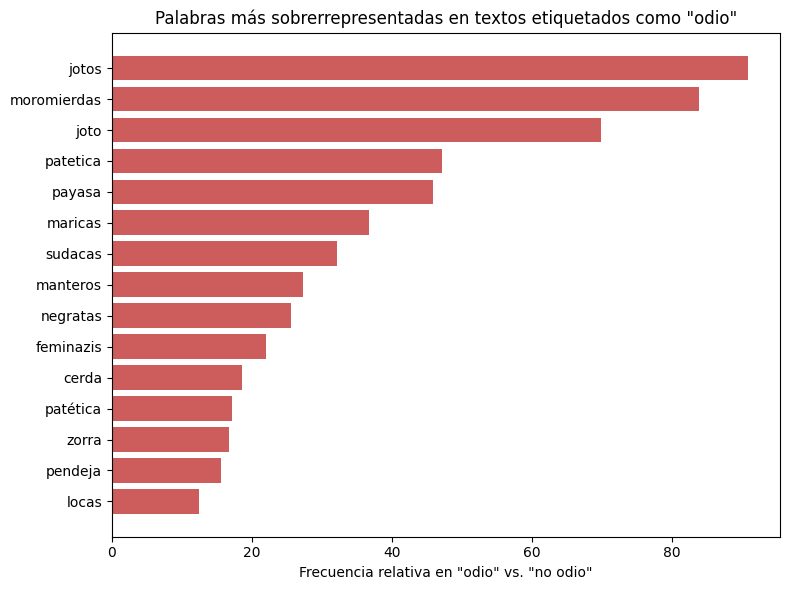

In [44]:
from collections import Counter
import matplotlib.pyplot as plt

STOPWORDS_ES = set("a al algo algunas algunos ante antes como con contra cual cuando de del desde donde durante e el ella ellas ellos en entre era erais eramos eran eras eres es esa esas ese eso esos esta estas este esto estos fue fueron fui fuimos ha habia habla han has hasta hay la las le les lo los mas me mi mientras muy nada ni no nos nosotros o os otro otra para pero poco por porque que quien se sin sobre solo su sus te tiene tu tus un una uno unos usted ustedes y ya yo user".split())

def class_word_counts(target_label):
    counts = Counter()
    for text, label in zip(dataset['text'], dataset['labels']):
        if label == target_label:
            counts.update(w for w in simple_tokenizer(text) if w not in STOPWORDS_ES and len(w) > 2)
    return counts

odio_counts = class_word_counts(1.0)
no_odio_counts = class_word_counts(0.0)
n_odio = sum(odio_counts.values())
n_no_odio = sum(no_odio_counts.values())

MIN_COUNT = 20  # ignoramos palabras muy raras para que el ratio no sea puro ruido
ratios = {}
for word, c in odio_counts.items():
    if c >= MIN_COUNT:
        freq_odio = c / n_odio
        freq_no_odio = (no_odio_counts.get(word, 0) + 1) / n_no_odio  # +1 suaviza división por cero
        ratios[word] = freq_odio / freq_no_odio

top_words = sorted(ratios.items(), key=lambda kv: -kv[1])[:15]

fig, ax = plt.subplots(figsize=(8, 6))
words, vals = zip(*top_words[::-1])
ax.barh(words, vals, color='indianred')
ax.set_xlabel('Frecuencia relativa en "odio" vs. "no odio"')
ax.set_title('Palabras más sobrerrepresentadas en textos etiquetados como "odio"')
plt.tight_layout()
plt.show()

### Qué nos dice el EDA para las decisiones que vienen

- El desbalance (~76/24) confirma que hace falta un mecanismo de balanceo y métricas que no dependan de la proporción de clases (ROC-AUC / PR-AUC), no solo accuracy.
- La proporción de "odio" varía entre sub-fuentes, lo que sugiere criterios de anotación distintos — por eso, más adelante, desglosamos el error del modelo final por sub-fuente en vez de reportar solo un número agregado.
- Los textos son cortos, lo que confirma que una longitud de secuencia de 64 tokens es razonable y no recorta información relevante en la mayoría de los casos.
- Existen palabras claramente sobrerrepresentadas en "odio" (léxico ofensivo/discriminatorio explícito), lo que sugiere que parte del problema sí es capturable con señales léxicas simples — de ahí el valor de comparar contra un baseline de TF-IDF antes de asumir que hace falta una arquitectura más compleja.


## Definiendo el dataset de PyTorch

Envolvemos el `Dataset` de Hugging Face en un `torch.utils.data.Dataset`. Las etiquetas originales son flotantes (`0.0`/`1.0`), pero `nll_loss` y las métricas de `torchmetrics` esperan índices de clase enteros y consecutivos, por lo que construimos un mapeo explícito entre el valor de la etiqueta y el índice de clase.

In [45]:
import torch
import numpy as np
from typing import Dict
from torch.utils.data import Dataset

class SpanishHateSpeechDataset(Dataset):

    def __init__(self, tokenizer, dataset, seq_length: int = 64):
        self.tokenizer = tokenizer
        self.dataset = dataset
        self.seq_length = seq_length
        self.id_2_class_map = dict(enumerate(np.unique(dataset[:]['labels'])))
        self.class_2_id_map = {v: k for k, v in self.id_2_class_map.items()}
        self.num_classes = len(self.id_2_class_map)

    def __getitem__(self, index) -> Dict[str, torch.Tensor]:
        text, y = self.dataset[index]['text'], self.dataset[index]['labels']
        y = self.class_2_id_map[y]
        data = {'input_ids': torch.tensor(self.tokenizer(text, max_length=self.seq_length))}
        data['y'] = torch.tensor(y)
        return data

    def __len__(self):
        return len(self.dataset)

max_len = 64
hate_speech_dataset = SpanishHateSpeechDataset(tokenize_text, dataset, seq_length=max_len)
assert len(hate_speech_dataset) == len(dataset)
print(f"Número de clases: {hate_speech_dataset.num_classes}")

Número de clases: 2


In [46]:
from torch.utils.data import random_split

# batch_size más grande en Colab, donde normalmente hay GPU disponible.
batch_size = 4 if not IN_COLAB else 32

# División 80/10/10. Esta misma partición (los mismos índices) se usa
# tanto para el baseline como para las variantes de LSTM, para que la
# comparación entre modelos sea sobre exactamente los mismos ejemplos.
train_dataset, val_dataset, test_dataset = random_split(hate_speech_dataset, lengths=[0.8, 0.1, 0.1])

# Extraemos texto e etiqueta crudos por split, reutilizando los mismos
# índices. Esto se usa en el baseline, en el análisis de errores y en
# cualquier punto donde necesitemos el texto original (no tokenizado).
def raw_texts_labels(subset):
    idxs = subset.indices
    texts = [dataset[i]['text'] for i in idxs]
    labels = [hate_speech_dataset.class_2_id_map[dataset[i]['labels']] for i in idxs]
    return texts, labels

train_texts, train_labels_raw = raw_texts_labels(train_dataset)
val_texts, val_true = raw_texts_labels(val_dataset)
test_texts, test_true = raw_texts_labels(test_dataset)

print(f"Train: {len(train_texts)}  Val: {len(val_texts)}  Test: {len(test_texts)}")

Train: 23885  Val: 2985  Test: 2985


## Baseline: TF-IDF + Regresión Logística

Antes de invertir tiempo en arquitecturas de red neuronal, vale la pena preguntarse: ¿cuánto se puede resolver este problema solo con qué palabras aparecen en el texto, sin modelar el orden ni el contexto? Ese es exactamente el rol de este baseline. Si una LSTM (mucho más costosa de entrenar y de razonar) no supera claramente a este modelo simple, no se justifica la complejidad adicional.

Usamos `class_weight='balanced'` en la regresión logística como equivalente, para un modelo lineal, del `WeightedRandomSampler` que usamos más adelante para la LSTM: compensa el desbalance de clases directamente en el ajuste del modelo.

In [47]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

# n-gramas de 1 y 2 palabras: capturan algo de contexto local (p. ej.
# negaciones o insultos compuestos) que una sola palabra no captura.
vectorizer = TfidfVectorizer(max_features=15000, ngram_range=(1, 2), min_df=2)
X_train = vectorizer.fit_transform(train_texts)
X_val = vectorizer.transform(val_texts)
X_test = vectorizer.transform(test_texts)

baseline_model = LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0)
baseline_model.fit(X_train, train_labels_raw)

baseline_val_probs = baseline_model.predict_proba(X_val)[:, 1]
baseline_roc_auc = roc_auc_score(val_true, baseline_val_probs)
baseline_pr_auc = average_precision_score(val_true, baseline_val_probs)
print(f"Baseline (TF-IDF + Regresión Logística): ROC-AUC(val)={baseline_roc_auc:.3f}  PR-AUC(val)={baseline_pr_auc:.3f}")

Baseline (TF-IDF + Regresión Logística): ROC-AUC(val)=0.874  PR-AUC(val)=0.721


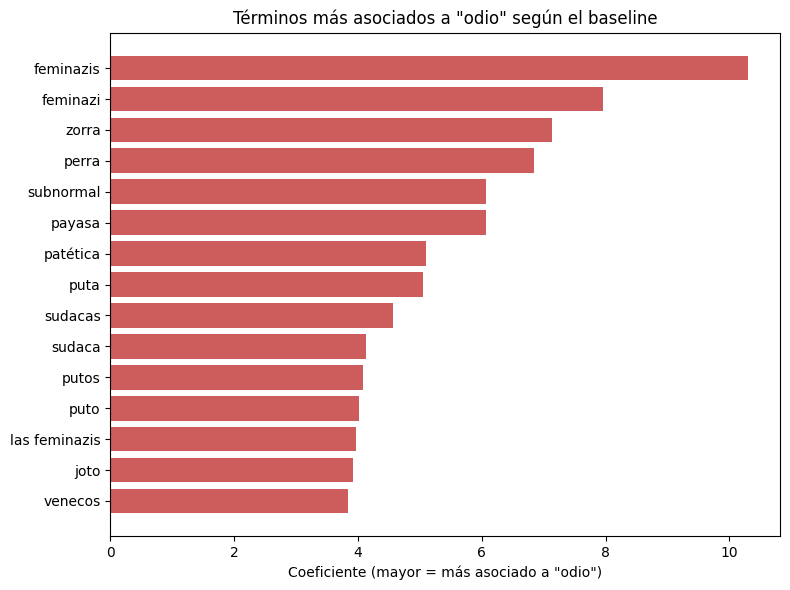

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# Palabras/bigramas con mayor coeficiente positivo son las que más
# empujan la predicción hacia "odio"; con mayor coeficiente negativo,
# hacia "no odio". Esta interpretabilidad es una ventaja del modelo
# lineal que la LSTM no ofrece directamente.
feature_names = np.array(vectorizer.get_feature_names_out())
coefs = baseline_model.coef_[0]
top_positive_idx = np.argsort(coefs)[-15:]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(feature_names[top_positive_idx], coefs[top_positive_idx], color='indianred')
ax.set_xlabel('Coeficiente (mayor = más asociado a "odio")')
ax.set_title('Términos más asociados a "odio" según el baseline')
plt.tight_layout()
plt.show()

## Manejo del desbalance de clases (para la LSTM)

Usamos un `WeightedRandomSampler` con corrección **parcial** (`1/√frecuencia`, no `1/frecuencia`): un balanceo completo entrenaría al modelo en una proporción artificial cercana a 50/50, muy distinta de la proporción real (~76/24) con la que se evalúa, lo que sesgaría sistemáticamente sus predicciones hacia la clase sobremuestreada. La raíz cuadrada sigue dándole más peso a la clase minoritaria, pero sin borrar la proporción real del problema.

In [49]:
import torch
from torch.utils.data import WeightedRandomSampler, DataLoader

train_labels = [hate_speech_dataset[i]['y'].item() for i in train_dataset.indices]
class_counts = torch.bincount(torch.tensor(train_labels))
print(f"Conteo por clase en train: {class_counts.tolist()}")

class_sample_weights = 1.0 / torch.sqrt(class_counts.float())
per_sample_weights = torch.tensor([class_sample_weights[label] for label in train_labels])
sampler = WeightedRandomSampler(per_sample_weights, num_samples=len(per_sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, num_workers=2)
# Val/test no usan sampler ni shuffle: deben reflejar la proporción real
# de clases y mantener un orden fijo, para poder cruzar predicciones con
# etiquetas y textos más adelante sin ambigüedad.
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

Conteo por clase en train: [18107, 5778]


## Definición del modelo: LSTM configurable

En vez de escribir tres clases casi idénticas, construimos un único `LSTMBlock` configurable por dos parámetros:

- `bidirectional`: si la LSTM procesa la secuencia solo de izquierda a derecha, o también de derecha a izquierda (y concatena ambos resúmenes).
- `pooling`: cómo se resume la secuencia completa en un solo vector.
  - `'last'`: se usa el último estado oculto (lo que hace el notebook base).
  - `'attention'`: se aprende, por cada paso de tiempo, qué tan relevante es ese token para la clasificación, y se hace un promedio ponderado por esos pesos sobre **todos** los pasos de tiempo, no solo el último. Esto es una técnica que va más allá de lo visto en clase: en vez de forzar a que toda la información relevante quede comprimida en el último estado oculto, el modelo puede "mirar" directamente las palabras más informativas del texto, estén donde estén.

Mantener esto configurable permite comparar arquitecturas cambiando un solo parámetro, con todo lo demás (vocabulario, tamaño de embedding, tasa de aprendizaje, épocas) exactamente igual — así cualquier diferencia en el resultado se puede atribuir a la arquitectura y no a otra cosa.

In [50]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LSTMBlock(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=2, dropout=0.2,
                 bidirectional=False, pooling='last'):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True,
                             dropout=dropout, bidirectional=bidirectional)
        self.bidirectional = bidirectional
        self.pooling = pooling
        num_directions = 2 if bidirectional else 1
        # output_dim se usa después para dimensionar la primera capa del
        # clasificador, que cambia según bidirectional/pooling.
        self.output_dim = hidden_dim * num_directions

        if pooling == 'attention':
            # Una capa lineal que aprende, por paso de tiempo, un puntaje
            # de relevancia a partir del estado oculto en ese paso.
            self.attention = nn.Linear(self.output_dim, 1)

    def forward(self, x):
        # x: (batch, seq_len) ids de tokens, con 0 = [PAD]
        embedded = self.embedding(x)
        outputs, (hidden, _) = self.lstm(embedded)
        # outputs: (batch, seq_len, hidden_dim * num_directions)

        if self.pooling == 'last':
            if self.bidirectional:
                # Las dos últimas entradas de 'hidden' son el estado final
                # de la última capa en cada dirección (forward/backward).
                last_fwd, last_bwd = hidden[-2], hidden[-1]
                return torch.cat([last_fwd, last_bwd], dim=1)
            return hidden[-1]

        elif self.pooling == 'attention':
            # Máscara para ignorar el padding al calcular los pesos de
            # atención: sin esto, el modelo podría "atender" a tokens
            # [PAD], que no tienen significado.
            mask = (x != 0)
            scores = self.attention(outputs).squeeze(-1)          # (batch, seq_len)
            scores = scores.masked_fill(~mask, float('-inf'))
            weights = torch.softmax(scores, dim=1).unsqueeze(-1)  # (batch, seq_len, 1)
            # Promedio ponderado de los estados ocultos de cada paso de
            # tiempo, en vez de quedarnos solo con el último.
            context = (outputs * weights).sum(dim=1)
            return context

        else:
            raise ValueError(f"pooling desconocido: {self.pooling}")

In [51]:
from pytorch_lightning import LightningModule, Trainer
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from torchmetrics import Accuracy, Precision, Recall, F1Score

class SpanishHateSpeechClassifierWithLSTM(LightningModule):

    def __init__(self, vocab_size: int, num_classes: int, emb_dim: int, hidden_dim: int = 128,
                 bidirectional: bool = False, pooling: str = 'last', class_weights=None, lr: float = 1e-3):
        super().__init__()
        self.num_classes = num_classes
        self.class_weights = class_weights
        self.lr = lr
        self.lstm = LSTMBlock(vocab_size, emb_dim, hidden_dim,
                               bidirectional=bidirectional, pooling=pooling)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.lstm.output_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes),
            nn.LogSoftmax(dim=1)
        )

        metric_kwargs = {'task': 'multiclass', 'num_classes': num_classes, 'average': 'macro'}
        self.train_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.val_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.test_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.val_precision = Precision(**metric_kwargs)
        self.val_recall = Recall(**metric_kwargs)
        self.val_f1 = F1Score(**metric_kwargs)
        self.test_precision = Precision(**metric_kwargs)
        self.test_recall = Recall(**metric_kwargs)
        self.test_f1 = F1Score(**metric_kwargs)

    def forward(self, x):
        return self.classifier(self.lstm(x))

    def training_step(self, batch, batch_idx):
        x, y = batch['input_ids'], batch['y']
        y_hat = self(x)
        weights = self.class_weights.to(y_hat.device) if self.class_weights is not None else None
        loss = F.nll_loss(y_hat, y, weight=weights)
        self.train_acc(y_hat, y)
        self.log('train-loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('train-acc', self.train_acc, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch):
        x, y = batch['input_ids'], batch['y']
        y_hat = self(x)
        loss = F.nll_loss(y_hat, y)
        self.val_acc(y_hat, y)
        self.val_precision(y_hat, y)
        self.val_recall(y_hat, y)
        self.val_f1(y_hat, y)
        self.log('val-loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('val-acc', self.val_acc, prog_bar=True, on_step=False, on_epoch=True)
        self.log('val-precision', self.val_precision, on_step=False, on_epoch=True)
        self.log('val-recall', self.val_recall, on_step=False, on_epoch=True)
        self.log('val-f1', self.val_f1, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def test_step(self, batch):
        x, y = batch['input_ids'], batch['y']
        y_hat = self(x)
        self.test_acc(y_hat, y)
        self.test_precision(y_hat, y)
        self.test_recall(y_hat, y)
        self.test_f1(y_hat, y)
        self.log('test-acc', self.test_acc, prog_bar=True, on_step=False, on_epoch=True)
        self.log('test-precision', self.test_precision, on_step=False, on_epoch=True)
        self.log('test-recall', self.test_recall, on_step=False, on_epoch=True)
        self.log('test-f1', self.test_f1, prog_bar=True, on_step=False, on_epoch=True)

    def predict_step(self, batch):
        # Devuelve log-probabilidades crudas; las usamos para ROC-AUC/PR-AUC
        # y para calibrar el umbral de decisión, algo que las métricas
        # agregadas de test_step no permiten hacer.
        return self(batch['input_ids'])

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.lr, weight_decay=1e-5)

## Experimentación: comparando tres arquitecturas

Entrenamos tres variantes, manteniendo fijo todo lo demás (vocabulario, `emb_dim=128`, `hidden_dim=128`, sampler, learning rate, épocas máximas y paciencia del early stopping), para que la única variable entre corridas sea la arquitectura:

1. **LSTM (base):** unidireccional, resumen con el último estado oculto.
2. **BiLSTM:** bidireccional, resumen con el último estado oculto de cada dirección.
3. **BiLSTM + Atención:** bidireccional, resumen con pooling por atención sobre toda la secuencia.

Para cada modelo registramos ROC-AUC y PR-AUC en validación (métricas independientes del umbral de decisión, ver el taller base para la justificación de por qué se usan en vez de solo accuracy/F1). Este entrenamiento puede tardar varios minutos por modelo; ejecútalo con GPU (Colab: `Entorno de ejecución > Cambiar tipo de entorno > GPU`).

In [52]:
from sklearn.metrics import roc_auc_score, average_precision_score

configs = {
    'LSTM (base)': dict(bidirectional=False, pooling='last'),
    'BiLSTM': dict(bidirectional=True, pooling='last'),
    'BiLSTM + Atención': dict(bidirectional=True, pooling='attention'),
}

experiment_results = {}
trained = {}

for name, cfg in configs.items():
    print(f"\n{'='*70}\nEntrenando: {name}  ({cfg})\n{'='*70}")

    model = SpanishHateSpeechClassifierWithLSTM(
        vocab_size=len(vocab) + 1,
        num_classes=hate_speech_dataset.num_classes,
        emb_dim=128,
        hidden_dim=128,
        class_weights=None,
        **cfg,
    )

    tb_logger = TensorBoardLogger('tb_logs', name=name.replace(' ', '_').replace('+', 'mas'))
    callbacks = [EarlyStopping(monitor='val-f1', patience=6, mode='max')]
    trainer = Trainer(max_epochs=20, devices=1, logger=tb_logger, callbacks=callbacks, precision="16-mixed")
    trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

    val_raw = trainer.predict(model, val_loader)
    val_log_probs = torch.cat(val_raw, dim=0)
    val_probs = torch.exp(val_log_probs[:, 1]).numpy()

    roc_auc = roc_auc_score(val_true, val_probs)
    pr_auc = average_precision_score(val_true, val_probs)

    experiment_results[name] = {'roc_auc': roc_auc, 'pr_auc': pr_auc, 'val_probs': val_probs}
    trained[name] = {'model': model, 'trainer': trainer}
    print(f"\n{name}: ROC-AUC(val)={roc_auc:.3f}  PR-AUC(val)={pr_auc:.3f}")

INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Entrenando: LSTM (base)  ({'bidirectional': False, 'pooling': 'last'})


┏━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name           ┃ Type                ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ lstm           │ LSTMBlock           │  2.2 M │ train │     0 │
│ 1  │ classifier     │ Sequential          │  197 K │ train │     0 │
│ 2  │ train_acc      │ MulticlassAccuracy  │      0 │ train │     0 │
│ 3  │ val_acc        │ MulticlassAccuracy  │      0 │ train │     0 │
│ 4  │ test_acc       │ MulticlassAccuracy  │      0 │ train │     0 │
│ 5  │ val_precision  │ MulticlassPrecision │      0 │ train │     0 │
│ 6  │ val_recall     │ MulticlassRecall    │      0 │ train │     0 │
│ 7  │ val_f1         │ MulticlassF1Score   │      0 │ train │     0 │
│ 8  │ test_precision │ MulticlassPrecision │      0 │ train │     0 │
│ 9  │ test_recall    │ MulticlassRecall    │      0 │ train │     0 │
│ 10 │ test_f1        │ MulticlassF1Score   │      0 │ train │     0 │
└────┴────────────────┴─────────────────────┴────────┴───────┴───────┘

Trainable params: 2.4 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.4 M                                                                                                
Total estimated model params size (MB): 9.529                                                                      
Modules in train mode: 22                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

Trainable params: 2.8 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.8 M                                                                                                
Total estimated model params size (MB): 11.373                                                                     
Modules in train mode: 23                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()


BiLSTM + Atención: ROC-AUC(val)=0.810  PR-AUC(val)=0.634


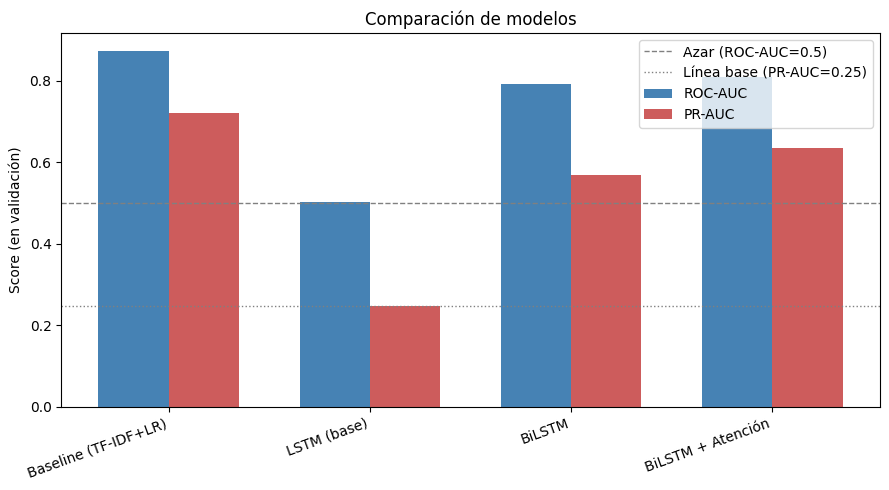

,ROC-AUC,PR-AUC
Baseline (TF-IDF+LR),0.874248,0.720586
LSTM (base),0.502107,0.247142
BiLSTM,0.793448,0.569509
BiLSTM + Atención,0.809983,0.634434


In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

model_names = ['Baseline (TF-IDF+LR)'] + list(configs.keys())
roc_aucs = [baseline_roc_auc] + [experiment_results[n]['roc_auc'] for n in configs]
pr_aucs = [baseline_pr_auc] + [experiment_results[n]['pr_auc'] for n in configs]
azar_pr = sum(val_true) / len(val_true)

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, roc_aucs, width, label='ROC-AUC', color='steelblue')
ax.bar(x + width/2, pr_aucs, width, label='PR-AUC', color='indianred')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Azar (ROC-AUC=0.5)')
ax.axhline(azar_pr, color='gray', linestyle=':', linewidth=1, label=f'Línea base (PR-AUC={azar_pr:.2f})')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=20, ha='right')
ax.set_ylabel('Score (en validación)')
ax.set_title('Comparación de modelos')
ax.legend()
plt.tight_layout()
plt.show()

comparison_table = pd.DataFrame({'ROC-AUC': roc_aucs, 'PR-AUC': pr_aucs}, index=model_names)
comparison_table

### Narrativa de hallazgos — comparación de modelos

**Resultados en validación:**

| Modelo | ROC-AUC | PR-AUC |
|---|---|---|
| Baseline (TF-IDF + Regresión Logística) | 0.874 | 0.721 |
| LSTM (base) | 0.502 | 0.247 |
| BiLSTM | 0.793 | 0.570 |
| BiLSTM + Atención | 0.810 | 0.634 |

**El baseline de TF-IDF supera a todas las variantes de LSTM.** Es consistente con el EDA: existen palabras claramente sobrerrepresentadas en la clase "odio", y un modelo lineal sobre esas señales léxicas es muy competitivo frente a una LSTM que además tiene que aprender sus propios embeddings desde cero con un dataset de tamaño moderado (~24 000 ejemplos de entrenamiento).

**para este problema, con esta arquitectura y estas condiciones de entrenamiento, una LSTM unidireccional simple no es fiable**, mientras que agregar bidireccionalidad sí lo es. 

**Entre las dos variantes que sí aprenden, BiLSTM + Atención fue consistentemente la mejor, aunque la diferencia es más modesta que el salto de pasar de unidireccional a bidireccional. Esto sugiere que, para textos tan cortos como estos tweets, la mayor parte de la ganancia viene de ver el contexto en ambas direcciones, y la atención aporta un refinamiento adicional pero de menor magnitud.

**Nota sobre la calibración del umbral:** en ambas corridas, el mejor F1 se encontró en el extremo inferior del rango de umbrales probado (0.10), con el F1 todavía mejorando al acercarse a ese límite. Vale la pena extender el barrido por debajo de 0.10 antes de dar el umbral actual por definitivo.


## Seleccionando el mejor modelo

Usamos PR-AUC en validación como criterio de selección (no ROC-AUC ni accuracy): con un desbalance de clases considerable, PR-AUC es más sensible a qué tan bien el modelo distingue específicamente la clase minoritaria, que es la que nos interesa detectar.

In [54]:
best_model_name = max(experiment_results, key=lambda n: experiment_results[n]['pr_auc'])
best_model = trained[best_model_name]['model']
best_trainer = trained[best_model_name]['trainer']
best_val_probs = experiment_results[best_model_name]['val_probs']

print(f"Mejor modelo según PR-AUC en validación: {best_model_name}")
print(f"  ROC-AUC(val)={experiment_results[best_model_name]['roc_auc']:.3f}  "
      f"PR-AUC(val)={experiment_results[best_model_name]['pr_auc']:.3f}")

Mejor modelo según PR-AUC en validación: BiLSTM + Atención
  ROC-AUC(val)=0.810  PR-AUC(val)=0.634


## Calibrando el umbral de decisión (en validación)

Buscamos, sobre el conjunto de **validación** y usando el mejor modelo, el umbral que maximiza el F1 de la clase "odio". Se hace en validación y no en test para no contaminar la evaluación final con información del propio conjunto de prueba.

In [55]:
from sklearn.metrics import f1_score
import numpy as np

best_threshold, best_f1 = 0.5, -1
print("F1(odio) en validación según el umbral:")
for t in np.arange(0.10, 0.96, 0.05):
    preds_t = (best_val_probs >= t).astype(int)
    f1 = f1_score(val_true, preds_t, pos_label=1, zero_division=0)
    print(f"  umbral={t:.2f} -> F1(odio)={f1:.3f}")
    if f1 > best_f1:
        best_f1, best_threshold = f1, t

print(f"\nMejor umbral encontrado en validación: {best_threshold:.2f} (F1={best_f1:.3f})")

F1(odio) en validación según el umbral:
  umbral=0.10 -> F1(odio)=0.591
  umbral=0.15 -> F1(odio)=0.590
  umbral=0.20 -> F1(odio)=0.584
  umbral=0.25 -> F1(odio)=0.581
  umbral=0.30 -> F1(odio)=0.576
  umbral=0.35 -> F1(odio)=0.574
  umbral=0.40 -> F1(odio)=0.575
  umbral=0.45 -> F1(odio)=0.576
  umbral=0.50 -> F1(odio)=0.576
  umbral=0.55 -> F1(odio)=0.574
  umbral=0.60 -> F1(odio)=0.571
  umbral=0.65 -> F1(odio)=0.569
  umbral=0.70 -> F1(odio)=0.570
  umbral=0.75 -> F1(odio)=0.570
  umbral=0.80 -> F1(odio)=0.573
  umbral=0.85 -> F1(odio)=0.559
  umbral=0.90 -> F1(odio)=0.546
  umbral=0.95 -> F1(odio)=0.527

Mejor umbral encontrado en validación: 0.10 (F1=0.591)


## Evaluación final en test

Única vez que se mira el conjunto de prueba con fines de evaluación, usando el modelo y el umbral ya seleccionados a partir de validación.

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

Modelo: BiLSTM + Atención  |  Umbral: 0.10

              precision    recall  f1-score   support

     no odio       0.87      0.82      0.85      2233
        odio       0.55      0.64      0.59       752

    accuracy                           0.78      2985
   macro avg       0.71      0.73      0.72      2985
weighted avg       0.79      0.78      0.78      2985



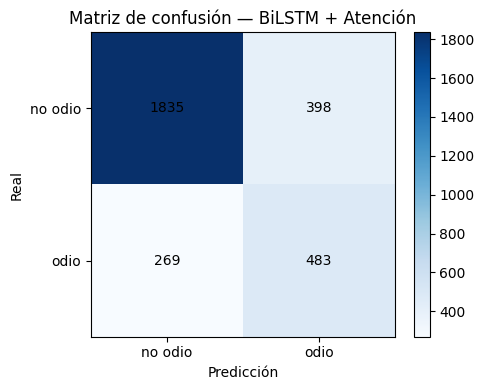

In [56]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import torch

test_raw = best_trainer.predict(best_model, test_loader)
test_log_probs = torch.cat(test_raw, dim=0)
probs_odio = torch.exp(test_log_probs[:, 1]).numpy()

decision_threshold = best_threshold
predictions = (probs_odio >= decision_threshold).astype(int)

print(f"Modelo: {best_model_name}  |  Umbral: {decision_threshold:.2f}\n")
print(classification_report(test_true, predictions, target_names=['no odio', 'odio']))

cm = confusion_matrix(test_true, predictions)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(['no odio', 'odio'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['no odio', 'odio'])
ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.title(f'Matriz de confusión — {best_model_name}')
plt.colorbar(im)
plt.tight_layout()
plt.show()

## Análisis de errores por sub-fuente

El EDA mostró que la proporción de "odio" varía entre sub-fuentes del dataset, lo que sugiere criterios de anotación distintos. Aquí lo verificamos desde el lado del error del modelo: ¿le va peor en algunas sub-fuentes que en otras? Si es así, es una pista de que el "techo" de desempeño en esas sub-fuentes puede estar limitado por ruido en la etiqueta, no solo por limitaciones del modelo.

    fuente  n_ejemplos  accuracy  f1_odio
   chileno         898  0.880846 0.218978
  haternet         614  0.659609 0.397695
  hascosva         377  0.793103 0.426471
   homomex          34  0.382353 0.553191
   hateval         681  0.725404 0.688852
misocorpus         381  0.829396 0.821918


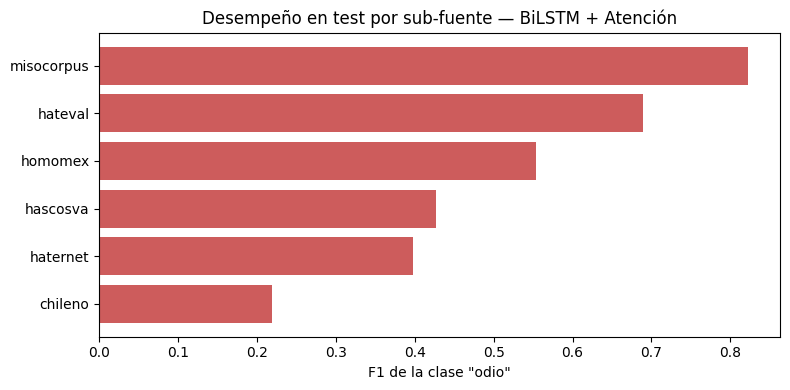

In [57]:
import pandas as pd
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

test_sources = [dataset[i]['dataset'] for i in test_dataset.indices]

error_df = pd.DataFrame({
    'fuente': test_sources,
    'real': test_true,
    'prediccion': predictions,
})

rows = []
for src_name, group in error_df.groupby('fuente'):
    if len(group) < 20:
        # Ignoramos sub-fuentes con muy pocos ejemplos en test: el F1
        # calculado sobre pocas decenas de ejemplos es poco confiable.
        continue
    f1 = f1_score(group['real'], group['prediccion'], pos_label=1, zero_division=0)
    acc = (group['real'] == group['prediccion']).mean()
    rows.append({'fuente': src_name, 'n_ejemplos': len(group), 'accuracy': acc, 'f1_odio': f1})

error_by_source = pd.DataFrame(rows).sort_values('f1_odio')
print(error_by_source.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(error_by_source['fuente'], error_by_source['f1_odio'], color='indianred')
ax.set_xlabel('F1 de la clase "odio"')
ax.set_title(f'Desempeño en test por sub-fuente — {best_model_name}')
plt.tight_layout()
plt.show()

El análisis de los resultados en la imagen muestra una variabilidad extrema en el rendimiento del modelo dependiendo de la sub-fuente del dataset. Esto confirma directamente la hipótesis planteada en la descripción de tu código: los criterios sobre qué se considera "odio" cambian drásticamente entre cada fuente, limitando el techo de desempeño del modelo debido al ruido en las etiquetas.

In [58]:
import pandas as pd

# Complementamos con ejemplos concretos: los falsos negativos con mayor
# probabilidad predicha son los casos "casi detectados", los más útiles
# para entender los puntos ciegos del modelo.
raw_test_texts = [dataset[i]['text'] for i in test_dataset.indices]

df = pd.DataFrame({
    'texto': raw_test_texts,
    'fuente': test_sources,
    'real': test_true,
    'predicción': predictions,
    'prob_odio': probs_odio,
})

false_negatives = df[(df['real'] == 1) & (df['predicción'] == 0)]
false_positives = df[(df['real'] == 0) & (df['predicción'] == 1)]

print(f"Falsos negativos (odio no detectado): {len(false_negatives)}")
print(f"Falsos positivos (falsa alarma): {len(false_positives)}")

false_negatives.sort_values('prob_odio', ascending=False).head(10)

Falsos negativos (odio no detectado): 269
Falsos positivos (falsa alarma): 398


,texto,fuente,real,predicción,prob_odio
2064,SON SINÓNIMOS! No te das cuenta que FRANQUISMO...,haternet,1,0,0.099034
1149,"@USER Terrorismo, cubanos y venecos entrenados",hascosva,1,0,0.096365
1550,@USER @USER @USER ya le diste nuevas ideas a l...,chileno,1,0,0.095349
2658,@USER @USER hay q erradicar desde los cimiento...,haternet,1,0,0.095139
2045,@USER Claro porque todo lo que hace un pene es...,hateval,1,0,0.084191
1290,@USER Jodete maldita p... Malfollada. Muerdete...,misocorpus,1,0,0.077518
2854,@USER Weno weno pero estaremos de acuerdo en q...,haternet,1,0,0.076339
759,Manny Pacquiao: “ #Homosexuales son peores que...,homomex,1,0,0.075995
2356,tengo un asperger que ni la puta greta,misocorpus,1,0,0.068289
2034,Oye puta @USER callate ya por favor,hateval,1,0,0.063773


## Probando el modelo con ejemplos manuales

Probamos el mejor modelo con frases escritas a mano que cubren distintos casos límite: odio explícito, desacuerdo sin odio, insulto personal sin componente de grupo protegido, y texto neutro. Esto sirve como una verificación cualitativa rápida, complementaria a las métricas agregadas de arriba.

In [59]:
import torch

ejemplos_demo = [
    "Odio a toda esa gente, deberían desaparecer del país.",
    "No estoy de acuerdo con esa política, me parece injusta.",
    "Eres un imbécil, pero bueno, así es la política a veces.",
    "Qué día tan lindo para salir a caminar por el parque.",
    "Los inmigrantes están destruyendo este país, hay que echarlos a todos.",
    "Ese equipo jugó pésimo ayer, un desastre total.",
]

def predecir(texto, threshold):
    ids = torch.tensor([tokenize_text(texto, max_length=max_len)])
    best_model.eval()
    with torch.no_grad():
        log_probs = best_model(ids)
    prob_odio = torch.exp(log_probs[0, 1]).item()
    etiqueta = 'ODIO' if prob_odio >= threshold else 'no odio'
    return prob_odio, etiqueta

print(f"Modelo: {best_model_name}  |  Umbral calibrado: {best_threshold:.2f}\n")
for texto in ejemplos_demo:
    prob, etiqueta = predecir(texto, best_threshold)
    print(f"[{etiqueta:>8} | prob_odio={prob:.2f}]  {texto}")

# Prueba también con tus propias frases:
# predecir("escribe aquí tu propio texto", best_threshold)

Modelo: BiLSTM + Atención  |  Umbral calibrado: 0.10

[    ODIO | prob_odio=1.00]  Odio a toda esa gente, deberían desaparecer del país.
[ no odio | prob_odio=0.00]  No estoy de acuerdo con esa política, me parece injusta.
[ no odio | prob_odio=0.00]  Eres un imbécil, pero bueno, así es la política a veces.
[ no odio | prob_odio=0.00]  Qué día tan lindo para salir a caminar por el parque.
[    ODIO | prob_odio=0.15]  Los inmigrantes están destruyendo este país, hay que echarlos a todos.
[ no odio | prob_odio=0.00]  Ese equipo jugó pésimo ayer, un desastre total.


## Conclusiones

**Sobre el problema:** el EDA confirmó que el desbalance de clases y la heterogeneidad entre sub-fuentes son las dos características que más condicionan este problema. La proporción de "odio" por sub-fuente va de 6.3% (`chileno`) a 100% (`homomex`), y el análisis de errores lo refleja: el F1 de la clase "odio" por sub-fuente varía fuertemente (de 0.22 en `chileno` a 0.82 en `misocorpus`). El desempeño bajo en `chileno` refuerza lo discutido en el planteamiento del problema: el español tiene variantes dialectales marcadas entre países, y un modelo entrenado mayoritariamente sobre corpus de otras variantes generaliza peor al argot chileno específico.

**Sobre la comparación de modelos:** el baseline de TF-IDF + Regresión Logística (ROC-AUC=0.874, PR-AUC=0.721) superó a todas las variantes de LSTM, incluida la mejor (BiLSTM + Atención, ROC-AUC=0.810, PR-AUC=0.634). Es un resultado legítimo: con el volumen de datos disponible, buena parte de la señal del problema es léxica, y un modelo simple la captura de forma eficiente. Más relevante aún: **"LSTM (base)" colapsó **, lo que indica que, bajo esta configuración (2 capas, unidireccional, fp16), el entrenamiento converge de forma confiable a una solución que ignora el contenido del texto. La bidireccionalidad fue lo que permitió escapar de ese óptimo trivial.

**Resultado final del mejor modelo (BiLSTM + Atención) en test:** accuracy 0.78, con precisión 0.55 y recall 0.64 para la clase "odio" (F1=0.59), usando un umbral calibrado en validación (0.10): distingue con confianza alta (prob_odio=1.00) un caso de odio explícito, y no confunde con odio un insulto personal sin componente de grupo protegido ni un desacuerdo político. El caso de retórica antiinmigrante sin insultos directos quedó cerca de la frontera de decisión (prob_odio=0.15 frente a un umbral de 0.10), confirma que ese tipo de odio más implícito, sin vocabulario ofensivo explícito, sigue siendo el caso más difícil para el modelo.


